In [14]:
# Core libraries for data handling, download, visualization, and cointegration tests
import pandas as pd
import yfinance as yf
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint


## Step 1: Build the Automated Scanner (Data Setup)

- Define a universe of 9 major U.S. sector ETFs.
- Download `Adj Close` price data from Yahoo Finance (2020-01-01 to 2026-05-01).
- The goal of this step is to build clean, comparable time series for cointegration testing.

In [2]:
tickers = ['XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB']
data = yf.download(tickers, start='2020-01-01', end='2026-05-01', auto_adjust=False)['Adj Close']
print(data)

[*********************100%***********************]  9 of 9 completed

Ticker            XLB        XLE        XLF         XLI         XLK  \
Date                                                                  
2020-01-02  26.765255  23.356089  27.642971   75.150536   44.294193   
2020-01-03  26.333132  23.286688  27.349461   75.005714   43.796169   
2020-01-06  26.218479  23.467890  27.331675   75.032852   43.900524   
2020-01-07  26.187613  23.406206  27.153795   74.878937   43.881542   
2020-01-08  26.280220  23.020668  27.331675   75.132446   44.351097   
...               ...        ...        ...         ...         ...   
2026-04-24  51.919998  56.869999  51.419998  172.470001  160.220001   
2026-04-27  51.779999  56.770000  51.810001  172.509995  160.570007   
2026-04-28  51.400002  57.709999  51.849998  170.979996  157.850006   
2026-04-29  50.959999  59.029999  51.919998  169.929993  159.110001   
2026-04-30  51.470001  59.650002  52.130001  174.580002  159.500000   

Ticker            XLP        XLU         XLV         XLY  
Date             

## Step 2: Analyze Scanner Results (Cointegration Filtering)

- Use `itertools.combinations` to test all ETF pair combinations.
- Apply the Engle-Granger `coint()` test and keep candidates with `p-value < 0.05`.
- Interpretation focus: smaller `p-value` means stronger statistical evidence, but the pair should also make economic/industry sense.

In [3]:
# Scan every ETF pair and keep only statistically cointegrated candidates
# Note: threshold 0.05 is a simple filter and may be tightened for robustness
def find_cointegrated_pairs(data):
    n = data.shape[1]
    keys = data.keys()
    pair = []

    for i, j in itertools.combinations(range(n), 2):
        stock_1 = data[keys[i]]
        stock_2 = data[keys[j]]
        score, pvalue, _ = coint(stock_1, stock_2)

        if pvalue < 0.05:
            pair.append((keys[i], keys[j], pvalue))

    return pair

In [11]:
# Convert scan results to a table and rank by strongest statistical evidence
cointegrated_pairs = find_cointegrated_pairs(data)
df_results = pd.DataFrame(cointegrated_pairs, columns=['Asset 1', 'Asset 2', 'p-value'])
print(df_results.sort_values('p-value'))

  Asset 1 Asset 2   p-value
0     XLI     XLK  0.013154


## Step 3: Deep Dive on the Best Pair (Hedge Ratio / Spread / Z-Score)

- Select the pair with the smallest `p-value` from the scan results.
- Estimate Hedge Ratio (`beta`) with OLS regression: `asset_2 = alpha + beta * asset_1`.
- Compute `spread = asset_2 - beta * asset_1` and inspect mean-reversion behavior.
- Standardize spread into Z-Score; if it oscillates around 0 in a stable way, the pair is usually more suitable for pairs trading.

<Axes: title={'center': 'Spread between XLK and XLI (Beta=1.00)'}, xlabel='Date'>

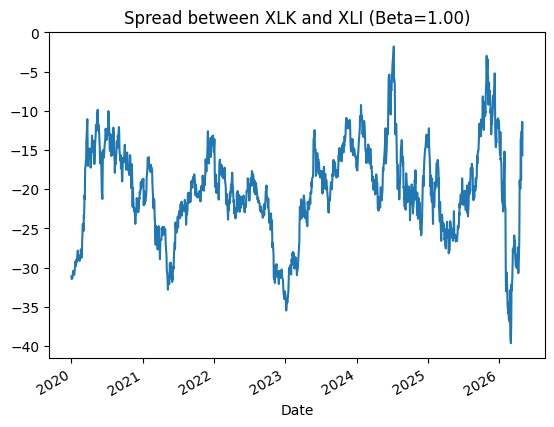

In [10]:
# Calculate hedge ratio for the best cointegrated pair
import statsmodels.api as sm

# Guard clause: fail fast if no pairs were found
if df_results.empty:
    raise ValueError("No cointegrated pairs found. Try a longer lookback or different tickers.")

# Select the pair with the lowest p-value
best_pair = df_results.sort_values("p-value").iloc[0]
asset_1 = best_pair["Asset 1"]
asset_2 = best_pair["Asset 2"]

# OLS regression: asset_2 = alpha + beta * asset_1
X = sm.add_constant(data[asset_1])
model = sm.OLS(data[asset_2], X, missing="drop").fit()
hedge_ratio = model.params[asset_1]

# Compute and plot spread using estimated hedge ratio
spread = data[asset_2] - hedge_ratio * data[asset_1]
spread.plot(title=f"Spread between {asset_2} and {asset_1} (Beta={hedge_ratio:.2f})")

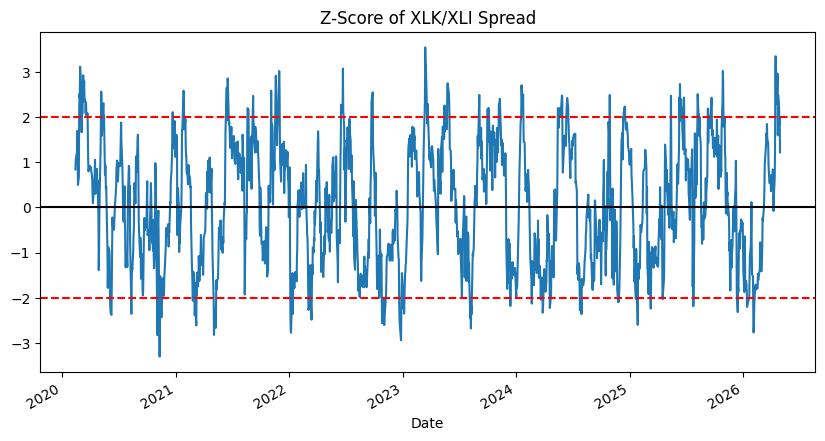

In [15]:
# Standardize spread into z-score for mean-reversion signal monitoring
window = 30
rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()
z_score = (spread - rolling_mean) / rolling_std

# Plot z-score with common entry/exit reference bands
z_score.plot(figsize=(10, 5), title="Z-Score of XLK/XLI Spread")
plt.axhline(2, color='red', linestyle='--')   # Upper band: spread is relatively rich
plt.axhline(-2, color='red', linestyle='--')  # Lower band: spread is relatively cheap
plt.axhline(0, color='black', linestyle='-')  # Mean-reversion center line
plt.show()


## Step 4: Conclusion

- The automated scan across 9 sector ETFs successfully identifies cointegrated candidates with potential mean-reversion behavior.
- In this run, `XLI` and `XLK` is the strongest pair for deeper analysis based on `p-value` ranking.
- Building spread with `beta` and monitoring Z-Score provides a practical foundation for signal design.
- Recommended next step: define entry/exit rules, include trading costs and stop-loss logic, and run a full backtest.

In [ ]:
## Notebook Notes

- The current scan finds `XLI` and `XLK` as the strongest cointegrated pair in this ETF universe.
- The spread is modeled as `asset_2 - beta * asset_1` and standardized into a 30-day z-score.
- The next step is to convert z-score thresholds into explicit entry/exit indicators and evaluate strategy behavior.